In [2]:
import pandas as pd
import ast
df = pd.read_csv('unified_results.csv')
laminate_database = pd.read_csv('laminate_database.csv', index_col='laminate_id')
df = pd.merge(
    left= df,
    right= laminate_database,
    how= 'inner',
    on= 'laminate_id'
)
df['ply_sequence'] = df['ply_sequence'].apply(ast.literal_eval)
df['orientation_at_defect'] = df.apply(lambda row: row['ply_sequence'][row['ply_with_defect_index'] - 1], axis=1)
df_reference_laminates = df[(df['defect_width'] == 0.0) & (df['ply_with_defect_index'] == 2)]
print(df_reference_laminates[['laminate_id', 'ply_sequence', 'equivalent_stiffness']])

     laminate_id                                       ply_sequence  \
0              1                   [45, 0, -45, 90, 90, -45, 0, 45]   
72             2  [45, 0, -45, 90, 0, -45, 0, 45, 45, 0, -45, 0,...   
240            3  [45, 0, -45, 90, 45, 0, -45, -45, 0, 45, 90, -...   
384            4  [0, 45, -45, 0, 90, 0, 45, 45, 0, 90, 0, -45, ...   
528            5  [45, 0, 90, 0, -45, 0, 90, 0, 0, 90, 0, -45, 0...   
696            6  [45, 0, -45, 90, -45, 0, 45, 90, 90, 45, 0, -4...   

     equivalent_stiffness  
0             4041.693733  
72            5517.446033  
240           4487.078895  
384           6126.169524  
528           6910.103200  
696           4041.693867  


In [3]:
table_reference = df_reference_laminates[['laminate_id', 'ply_sequence', 'equivalent_stiffness']]
latex_code = table_reference.to_latex(
    index=False,
    caption="Rigidez equivalente de los laminados sin defecto",
    label="tab:reference_stiffness",
    column_format="rlr",       # 'l' for text column, 'r' for numeric columns
    position="htbp",
    float_format="%.0f"         # Enforces strict decimal precision uniformly
)
print(latex_code)

\begin{table}[htbp]
\caption{Rigidez equivalente de los laminados sin defecto}
\label{tab:reference_stiffness}
\begin{tabular}{rlr}
\toprule
laminate_id & ply_sequence & equivalent_stiffness \\
\midrule
1 & [45, 0, -45, 90, 90, -45, 0, 45] & 4042 \\
2 & [45, 0, -45, 90, 0, -45, 0, 45, 45, 0, -45, 0, 90, -45, 0, 45] & 5517 \\
3 & [45, 0, -45, 90, 45, 0, -45, -45, 0, 45, 90, -45, 0, 45] & 4487 \\
4 & [0, 45, -45, 0, 90, 0, 45, 45, 0, 90, 0, -45, 45, 0] & 6126 \\
5 & [45, 0, 90, 0, -45, 0, 90, 0, 0, 90, 0, -45, 0, 90, 0, 45] & 6910 \\
6 & [45, 0, -45, 90, -45, 0, 45, 90, 90, 45, 0, -45, 90, -45, 0, 45] & 4042 \\
\bottomrule
\end{tabular}
\end{table}



## PLot Change in Laminate Equivalent Stiffness According to Defect Location

In [3]:
import numpy as np
laminates = np.arange(1,7,1)
laminates = [int(x) for x in laminates]
reference_indexes = df_reference_laminates.index.tolist()
print(reference_indexes[0])

0


In [3]:
df2 = df[(df['laminate_id'] == 1) & (df['defect_width'] == 1.0)]
df2 = df2[['ply_with_defect_index', 'orientation_at_defect', 'equivalent_stiffness']]
E_reference = df_reference_laminates.loc[0, 'equivalent_stiffness']
df2['E_percent_change'] = (-E_reference + df2['equivalent_stiffness']) / E_reference * 100
print(df2)

    ply_with_defect_index  orientation_at_defect  equivalent_stiffness  \
5                       2                      0           3967.322667   
17                      3                    -45           4044.038533   
29                      4                     90           4047.441967   
41                      5                     90           4047.947200   
53                      6                    -45           4037.704967   
65                      7                      0           3955.388200   

    E_percent_change  
5          -1.840097  
17          0.058015  
29          0.142223  
41          0.154724  
53         -0.098690  
65         -2.135380  


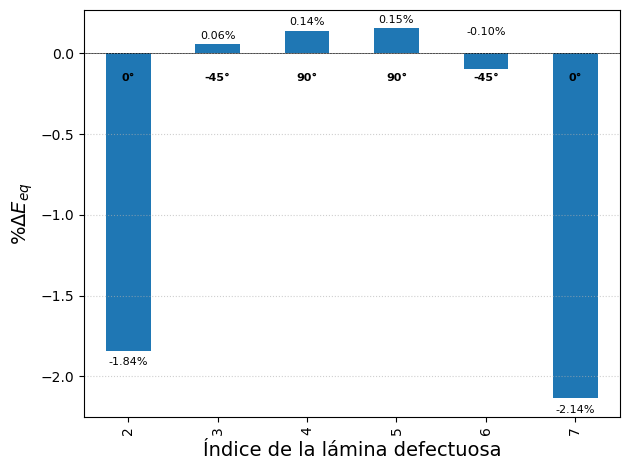

In [12]:
import matplotlib.pyplot as plt
target_directory = r'C:\Users\juanv\Documents\Work\01 Politecnico de Madrid\99 TFM\07 Graphs\\'
graph_name = 'L01_stiffness_vs_ply_defect_index'
filename = target_directory + graph_name + '.pdf'

set_fontsize = 14
ax = df2.plot(kind='bar', 
         x='ply_with_defect_index', 
         y='E_percent_change',
        legend = False)

ax.axhline(0, color='black', linewidth=0.5, zorder=1)
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
ax.set_ylim(-2.5, 0.5)

plt.xlabel('Índice de la lámina defectuosa', fontsize = set_fontsize)
plt.ylabel("%$\Delta E_{eq}$", fontsize = set_fontsize)

# Loop through each bar to place its value right at the y=0 line
for bar, (_, row) in zip(ax.patches, df2.iterrows()):
    val = bar.get_height()
    x_pos = bar.get_x() + bar.get_width() / 2
    

    orientation_at_defect = row['orientation_at_defect']
    orientation_label = orientation_at_defect
    
    # Position text at y=0, but push positive values UP and negative values DOWN
    if val >= 0 : 
        va_dir = 'top'
        y_pos = bar.get_height() + 0.02
    else:
        val_dir = 'bottom'
        y_pos = bar.get_height() - 0.1
    if (val < 0) & (val > -0.2):
        y_pos = 0.1
    
    ax.text(x_pos, y_pos, f"{val:.2f}%", ha='center', va=val_dir, fontsize=8)
    ax.text(x_pos, -0.18, f"{int(orientation_label):d}°", ha='center', va=val_dir, fontsize=8, fontweight='bold')

plt.tight_layout()
#plt.savefig(filename)
#plt.show()
plt.close()

In [35]:
for laminate in laminates:
    df2 = df[(df['laminate_id'] == laminate) & (df['defect_width'] == 1.0)]
    df2 = df2[['ply_with_defect_index', 'orientation_at_defect', 'equivalent_stiffness']]
    E_reference = df_reference_laminates.loc[reference_indexes[laminate - 1], 'equivalent_stiffness']
    df2['E_percent_change'] = (-E_reference + df2['equivalent_stiffness']) / E_reference * 100
    graph_name = 'L%02d_stiffness_vs_ply_defect_index'%(laminate)
    filename = target_directory + graph_name + '.pdf'
    max_y = df2['E_percent_change'].max()
    min_y = df2['E_percent_change'].min()
    
    set_fontsize = 14
    ax = df2.plot(kind='bar', 
             x='ply_with_defect_index', 
             y='E_percent_change',
            legend = False)
    
    ax.axhline(0, color='black', linewidth=0.5, zorder=1)
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)

    ax.set_ylim(min_y * 1.2, max_y * 1.8)
    
    plt.xlabel('Índice de la lámina defectuosa', fontsize = set_fontsize)
    plt.ylabel("%$\Delta E_{eq}$", fontsize = set_fontsize)
    
    # Loop through each bar to place its value right at the y=0 line
    for bar, (_, row) in zip(ax.patches, df2.iterrows()):
        val = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2
        
    
        orientation_at_defect = row['orientation_at_defect']
        orientation_label = orientation_at_defect
        
        # Position text at y=0, but push positive values UP and negative values DOWN
        if val >= 0 : 
            va_dir = 'top'
            y_pos = bar.get_height() + 0.02
        else:
            val_dir = 'bottom'
            y_pos = bar.get_height() * 1.1
        if (val < 0) & (val > -0.2):
            y_pos = 0.2 * max_y
        
        ax.text(x_pos, y_pos, f"{val:.2f}%", ha='center', va=val_dir, fontsize=8)
        ax.text(x_pos, 0.1 * min_y, f"{int(orientation_label):d}°", ha='center', va=val_dir, fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    #plt.savefig(filename)
    #plt.show()
    plt.close()

## Change in Laminate Rigidity, K, depending on defect position

In [39]:
for laminate in laminates:
    df2 = df[(df['laminate_id'] == laminate) & (df['defect_width'] == 1.0)]
    df2 = df2[['ply_with_defect_index', 'orientation_at_defect', 'laminate_rigidity']]
    K_reference = df_reference_laminates.loc[reference_indexes[laminate - 1], 'laminate_rigidity']
    df2['K_percent_change'] = (-K_reference + df2['laminate_rigidity']) / K_reference * 100
    graph_name = 'L%02d_rigidity_vs_ply_defect_index'%(laminate)
    filename = target_directory + graph_name + '.pdf'
    max_y = df2['K_percent_change'].max()
    min_y = df2['K_percent_change'].min()
    
    set_fontsize = 14
    ax = df2.plot(kind='bar', 
             x='ply_with_defect_index', 
             y='K_percent_change',
            legend = False)
    
    ax.axhline(0, color='black', linewidth=0.5, zorder=1)
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)

    ax.set_ylim(min_y * 1.2, max_y * 1.8)
    
    plt.xlabel('Índice de la lámina defectuosa', fontsize = set_fontsize)
    plt.ylabel("%$\Delta K_{eq}$", fontsize = set_fontsize)
    
    # Loop through each bar to place its value right at the y=0 line
    for bar, (_, row) in zip(ax.patches, df2.iterrows()):
        val = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2
        
    
        orientation_at_defect = row['orientation_at_defect']
        orientation_label = orientation_at_defect
        
        # Position text at y=0, but push positive values UP and negative values DOWN
        if val >= 0 : 
            va_dir = 'top'
            y_pos = bar.get_height() + 0.02
        else:
            val_dir = 'bottom'
            y_pos = bar.get_height() * 1.1
        if (val < 0) & (val > -0.2):
            y_pos = 0.2 * max_y
        
        ax.text(x_pos, y_pos, f"{val:.2f}%", ha='center', va=val_dir, fontsize=8)
        ax.text(x_pos, 0.1 * min_y, f"{int(orientation_label):d}°", ha='center', va=val_dir, fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    #plt.savefig(filename)
    #plt.show()
    plt.close()

## Change in Equivalent Stiffness according to defect width

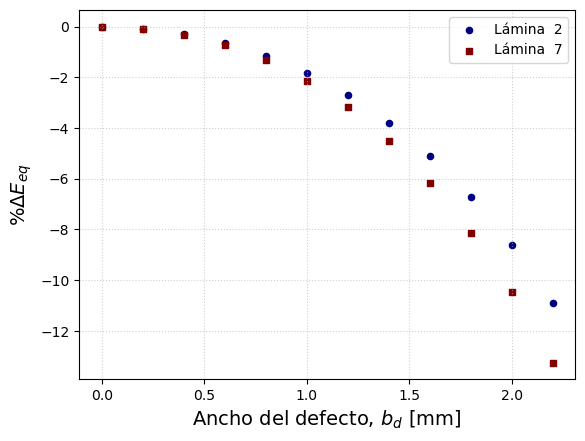

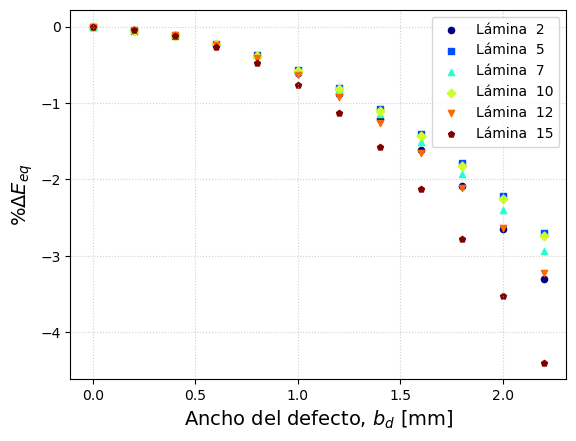

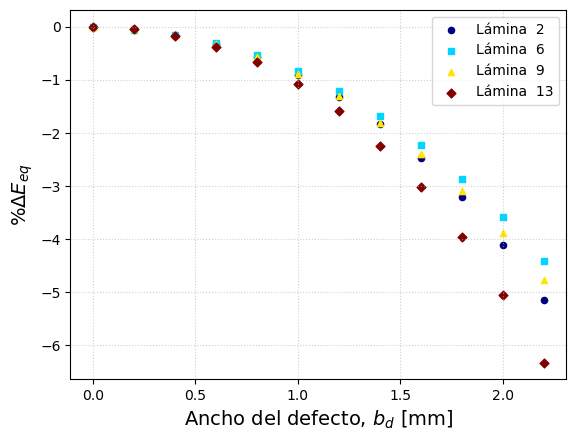

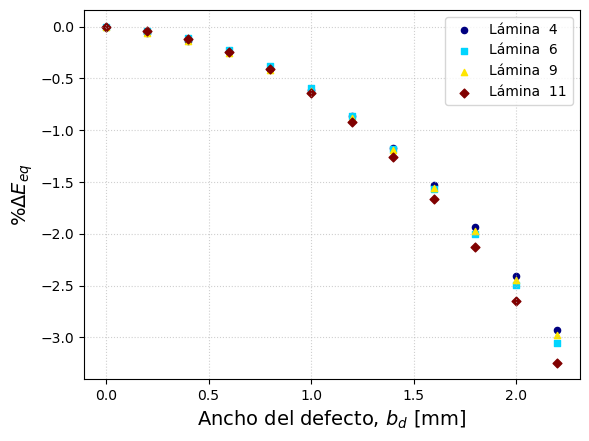

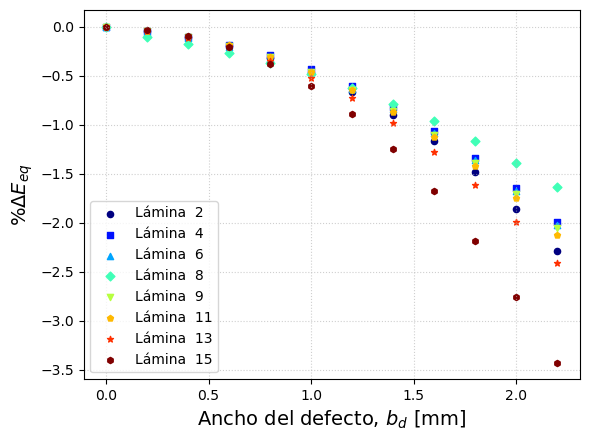

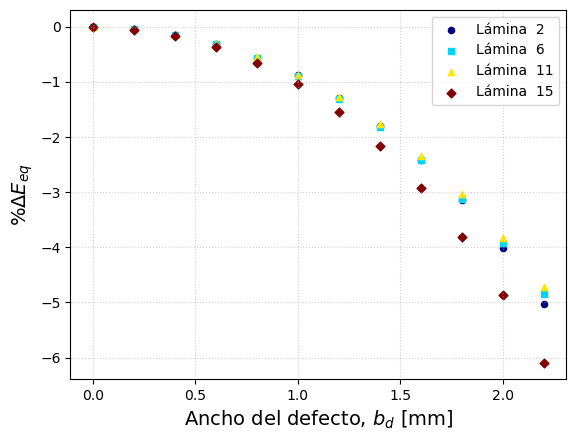

In [6]:
from itertools import cycle
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.pyplot as plt

target_directory = r'C:\Users\juanv\Documents\Work\01 Politecnico de Madrid\99 TFM\07 Graphs\\'

for laminate in laminates:
    set_fontsize = 14
    df2 = df[(df['laminate_id'] == laminate) & (df['orientation_at_defect'] == 0)]
    df2 = df2[['ply_with_defect_index', 'defect_width', 'equivalent_stiffness']]
    unique_plies = df2['ply_with_defect_index'].unique()
    E_reference = df_reference_laminates.loc[reference_indexes[laminate - 1], 'equivalent_stiffness']
    df2['E_percent_change'] = (-E_reference + df2['equivalent_stiffness']) / E_reference * 100
    graph_name = 'L%02d_stiffness_vs_defect_width'%(laminate)
    filename = target_directory + graph_name + '.pdf'
    max_y = df2['E_percent_change'].max()
    min_y = df2['E_percent_change'].min()
    
    markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', 'X', '<', '>']
    marker_pool = cycle(markers)
    
    cmap = mpl.colormaps['jet']  # 'turbo', 'viridis', 'plasma', 'jet', etc. have great contrast
    norm = mcolors.Normalize(vmin=0, vmax=len(unique_plies) - 1)
    
    fig, ax = plt.subplots()
    
    for i, ply in enumerate(unique_plies):
        df3 = df2[df2['ply_with_defect_index'] == ply]
        ply_color = cmap(norm(i))
        current_marker = next(marker_pool)
        ax = df3.plot(
            kind = 'scatter',
            x = 'defect_width',
            y = 'E_percent_change',
            label = f"Lámina {ply : 02d}",
            marker = current_marker,
            color=ply_color,
            ax = ax
        )
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.xlabel('Ancho del defecto, $b_d$ [mm]', fontsize = set_fontsize)
    plt.ylabel("%$\Delta E_{eq}$", fontsize = set_fontsize)
    
    #plt.savefig(filename)
    #plt.show()
    plt.close()